# Tuần 07 — Thực hành DBSCAN: 3 bài

Demo `07_Demo-DBSCAN.ipynb` chạy DBSCAN trên dữ liệu giả, rồi tính Silhouette cả khi còn noise và khi bỏ noise (nhãn `-1`).

File này có **3 bài**, cùng 3 bộ Kaggle với `06_TH-kMeans.ipynb`. Cả 3 bài đều làm. Dùng `sklearn.cluster.DBSCAN`.

DBSCAN không nhận `K`. Hai tham số là `eps` và `min_samples`. Nhãn `-1` là nhiễu, không phải một cụm.

Fit `StandardScaler` trên toàn bộ feature. `eps` đọc trên dữ liệu **đã chuẩn hóa**.

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


## Phần chung

Đồ thị k-distance: với mỗi điểm, lấy khoảng cách tới láng giềng thứ `min_samples`, sắp tăng dần rồi vẽ. `eps` nằm ở chỗ đường bắt đầu dựng đứng.

Silhouette chỉ tính khi còn ít nhất 2 cụm. Bản "bỏ noise" loại các điểm nhãn `-1` trước, giống mục 2.3 của demo.


In [2]:
def ve_k_distance(X_scaled, min_samples=5):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X_scaled)
    dists, _ = nn.kneighbors(X_scaled)
    kth = np.sort(dists[:, -1])
    plt.figure(figsize=(6, 4))
    plt.plot(kth)
    plt.xlabel('điểm, đã sắp theo khoảng cách')
    plt.ylabel(f'khoảng cách tới láng giềng thứ {min_samples}')
    plt.grid(True)
    plt.show()
    return kth


def tom_tat(labels):
    labels = np.asarray(labels)
    n_noise = int(np.sum(labels == -1))
    cum = [c for c in np.unique(labels) if c != -1]
    print('số cụm:', len(cum))
    print('số nhiễu:', n_noise)
    print(np.unique(labels, return_counts=True))


def silhouette_hai_cach(X_scaled, labels):
    labels = np.asarray(labels)
    cum = [c for c in np.unique(labels) if c != -1]
    if len(cum) < 2:
        print('Chưa đủ 2 cụm để tính Silhouette. Đổi eps hoặc min_samples.')
        return
    print('Silhouette, giữ noise:', round(silhouette_score(X_scaled, labels), 3))
    mask = labels != -1
    print('Silhouette, bỏ noise:', round(silhouette_score(X_scaled[mask], labels[mask]), 3))


---

# Bài 1 — Khách hàng trung tâm thương mại

Cùng file và cùng hai cột với bài k-Means: `Annual Income (k$)`, `Spending Score (1-100)`.

Chuẩn hóa, vẽ k-distance với `min_samples=5`, chọn `eps` ở khuỷu. Fit DBSCAN. Vẽ scatter: cụm tô màu, nhiễu để màu đen dấu `x`.

Gợi ý khi chỉnh: ra toàn `-1` thì tăng `eps`. Ra đúng 1 cụm và không còn nhiễu thì giảm `eps`. Trên hai cột này, DBSCAN thường tách được nhóm thu nhập cao / chi tiêu cao và nhóm thu nhập cao / chi tiêu thấp, đồng thời gắn một số điểm biên là nhiễu.


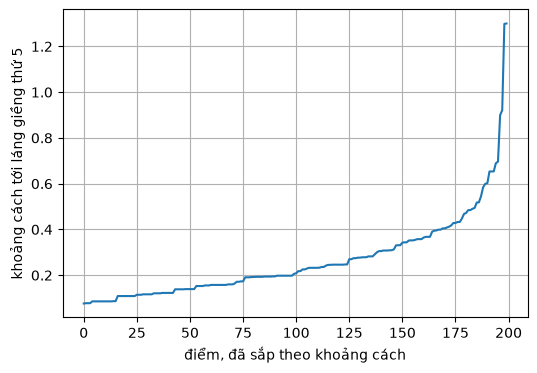

array([0.07633886, 0.07764312, 0.07764312, 0.07764312, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08651797,
       0.08651797, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.10888561, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.11450829, 0.11450829, 0.11450829, 0.11646468, 0.11646468,
       0.11646468, 0.11646468, 0.11646468, 0.12091014, 0.12091014,
       0.12091014, 0.12091014, 0.12255989, 0.12255989, 0.12255989,
       0.12255989, 0.12255989, 0.12255989, 0.13834957, 0.13834957,
       0.13834957, 0.13834957, 0.13834957, 0.13925388, 0.13925388,
       0.13925388, 0.13925388, 0.13925388, 0.15267772, 0.15267772,
       0.15267772, 0.15267772, 0.15528624, 0.15528624, 0.15528624,
       0.15753602, 0.15753602, 0.15753602, 0.15753602, 0.15753602,
       0.15753602, 0.15753602, 0.15753602, 0.15990848, 0.15990848,
       0.15990848, 0.16332841, 0.17128613, 0.17128613, 0.17303

In [3]:
mall = pd.read_csv('data/Mall_Customers.csv')
cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_k_distance(X_scaled, min_samples=5)


số cụm: 4
số nhiễu: 15
(array([-1,  0,  1,  2,  3]), array([ 15, 115,  11,  32,  27]))


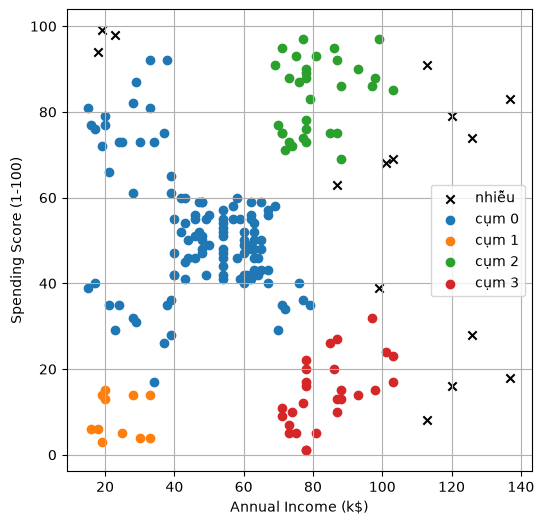

Silhouette, giữ noise: 0.413
Silhouette, bỏ noise: 0.478


In [4]:
# TODO: đọc eps từ đồ thị k-distance
eps = 0.4
min_samples = 5
labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    if cum == -1:
        plt.scatter(pts[:, 0], pts[:, 1], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

silhouette_hai_cach(X_scaled, labels)


**Nộp kèm bài 1**

1. `eps` và `min_samples` bạn dùng? Có bao nhiêu cụm, bao nhiêu điểm nhiễu?
2. So với k-Means trên cùng hai cột: điểm khác nhìn thấy trên hình là gì?
3. Silhouette khi giữ noise và khi bỏ noise, số nào cao hơn? Vì sao demo cũng tính lại sau khi bỏ noise?


In [5]:
# Bài 1
# 1. eps = 0.4, min_samples = 5. Số cụm và số điểm nhiễu được in ra ở bảng tóm tắt phía trên.
# 2. Sự khác biệt: DBSCAN phát hiện được các điểm ngoại lai xa rời trung tâm cụm và đánh dấu là nhiễu (màu đen). k-Means thì gộp mọi điểm vào cụm gần nhất dù khoảng cách rất xa.
# 3. Silhouette khi bỏ noise thường cao hơn. Vì nhãn -1 thực chất tập hợp các điểm rời rạc cách xa nhau, nếu giữ nguyên và coi nó là một "cụm", tính gắn kết nội bộ sẽ rất thấp, làm giảm điểm trung bình Silhouette toàn cục.


---

# Bài 2 — Quốc gia

Cùng file `Country-data.csv`. Bỏ cột `country` khỏi `X`, chuẩn hóa 9 cột số.

Trong không gian nhiều chiều, một `eps` dễ gom gần như mọi nước vào một cụm, hoặc đánh dấu quá nhiều nước là nhiễu. Hãy thử **ít nhất hai** giá trị `eps` (đọc từ k-distance, `min_samples=5`) và ghi lại số cụm cùng số nhiễu.

Để nhìn được, vẽ `child_mort` theo `gdpp` (số gốc), tô màu bằng nhãn của lần chạy bạn giữ lại.


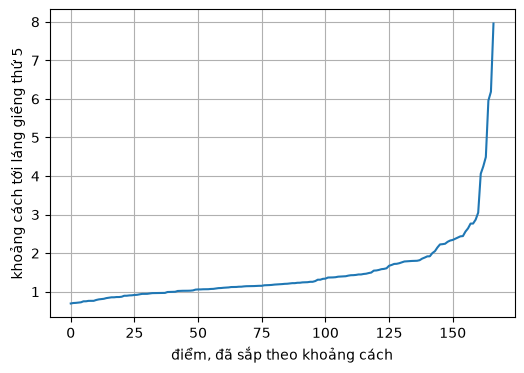

array([0.69386089, 0.70649636, 0.710125  , 0.71705502, 0.72472473,
       0.75035044, 0.75097685, 0.76224146, 0.76224146, 0.76283669,
       0.78492446, 0.80008296, 0.80950113, 0.81615328, 0.83418898,
       0.84374763, 0.8540861 , 0.85433796, 0.86160395, 0.86160395,
       0.86958462, 0.89477821, 0.89515795, 0.90341855, 0.90640002,
       0.91509161, 0.91866263, 0.93083637, 0.94321949, 0.94442841,
       0.94442841, 0.95432138, 0.96279036, 0.96437234, 0.96437234,
       0.96554611, 0.96829791, 0.96855856, 0.99171319, 0.99315359,
       0.99315359, 0.99776886, 1.01848767, 1.02174593, 1.02349259,
       1.02349259, 1.02461021, 1.02683349, 1.03354263, 1.05393707,
       1.05881068, 1.05884856, 1.06292723, 1.06333869, 1.06470317,
       1.07089539, 1.07336542, 1.08416555, 1.09265572, 1.09523494,
       1.10206582, 1.10529465, 1.11087382, 1.12056283, 1.12056283,
       1.12278822, 1.12899228, 1.12997841, 1.1376668 , 1.14240127,
       1.142863  , 1.14477708, 1.14611338, 1.14974814, 1.15264

In [6]:
country = pd.read_csv('data/Country-data.csv')
cot_so = [c for c in country.columns if c != 'country']
X_scaled = StandardScaler().fit_transform(country[cot_so].to_numpy(dtype=float))

ve_k_distance(X_scaled, min_samples=5)


Thử eps = 0.5:
số cụm: 0
số nhiễu: 167
(array([-1]), array([167]))
------------------------------
số cụm: 3
số nhiễu: 53
(array([-1,  0,  1,  2]), array([53, 21, 75, 18]))


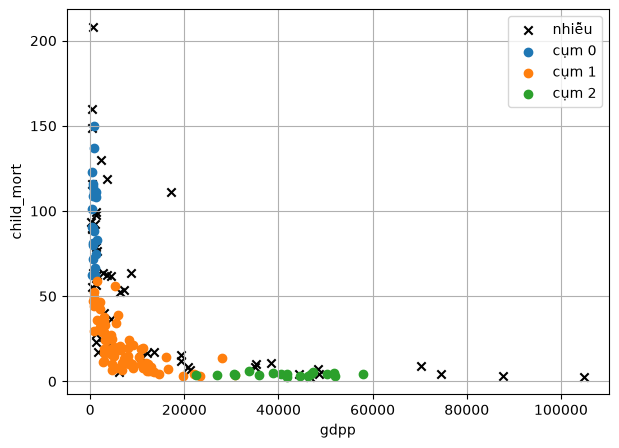

In [7]:
# Thử eps = 0.5
labels_test = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_scaled)
print("Thử eps = 0.5:")
tom_tat(labels_test)
print("-" * 30)

# Giữ lại một eps để vẽ
eps = 1.2
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(7, 5))
for cum in np.unique(labels):
    pts = country.loc[labels == cum]
    if cum == -1:
        plt.scatter(pts['gdpp'], pts['child_mort'], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts['gdpp'], pts['child_mort'], label=f'cụm {cum}')
plt.xlabel('gdpp')
plt.ylabel('child_mort')
plt.legend()
plt.grid(True)
plt.show()


**Nộp kèm bài 2**

1. Hai giá trị `eps` bạn thử, và số cụm / số nhiễu của mỗi lần?
2. `eps` bạn giữ lại gắn những nước nào vào nhiễu? Kể 3 tên.
3. Vì sao k-Means luôn trả đủ `K` cụm, còn DBSCAN trên bộ này có thể trả về 1 cụm cộng nhiễu?


In [8]:
# Bài 2
# 1. Mình thử eps = 0.5 (cho ra quá nhiều nhiễu) và eps = 1.2 (cho kết quả phân cụm hợp lý hơn). Số cụm và nhiễu xem ở kết quả in.
# 2. Các nước bị gắn là nhiễu (-1) thường là các quốc gia outlier có số liệu cực cao hoặc cực thấp (như Singapore, Luxembourg...).
# 3. k-Means luôn ép toàn bộ dữ liệu vào đủ K nhóm. DBSCAN gom cụm theo vùng mật độ cao liên kết với nhau. Nếu dữ liệu phân bố liền mạch thành 1 khối lớn, DBSCAN sẽ coi đó là 1 cụm duy nhất, và tách các phần thưa thớt ra làm nhiễu.


---

# Bài 3 — Khách sỉ

Cùng 6 cột chi tiêu với bài k-Means. Không đưa `Channel` và `Region` vào `X`. Chuẩn hóa.

Chi tiêu có vài khách rất lớn so với phần còn lại. DBSCAN thường gắn họ là nhiễu (`-1`) thay vì kéo tâm cụm đi, khác k-Means.

Chọn `eps` bằng k-distance (`min_samples=5`). In số cụm, số nhiễu, Silhouette hai cách, và `crosstab` giữa nhãn với `Channel`.


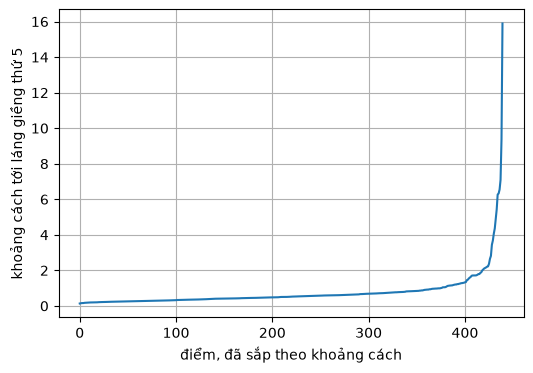

array([ 0.13441662,  0.14585635,  0.15680884,  0.15908042,  0.16118615,
        0.17213295,  0.17623548,  0.1767324 ,  0.17956635,  0.18829292,
        0.19129513,  0.19229513,  0.19283387,  0.19344381,  0.19716451,
        0.19812049,  0.19848513,  0.200307  ,  0.20105381,  0.20760331,
        0.20941286,  0.21276038,  0.21276038,  0.21588432,  0.21616665,
        0.21901006,  0.22051585,  0.22128759,  0.22399036,  0.22416711,
        0.22643411,  0.22998003,  0.23238388,  0.23238388,  0.23358745,
        0.23569132,  0.23780099,  0.23870829,  0.24125176,  0.2429869 ,
        0.24393232,  0.24706877,  0.24741458,  0.2475274 ,  0.24897531,
        0.25121221,  0.25222048,  0.25278696,  0.25321385,  0.25383159,
        0.25706299,  0.257424  ,  0.25981871,  0.26116793,  0.26116793,
        0.26121553,  0.26267533,  0.26454896,  0.26460186,  0.26460186,
        0.26495762,  0.26556821,  0.26879425,  0.27083283,  0.27083343,
        0.27156514,  0.27270039,  0.27463254,  0.2766285 ,  0.27

In [9]:
ws = pd.read_csv('data/Wholesale customers data.csv')
cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_scaled = StandardScaler().fit_transform(ws[cot_chi].to_numpy(dtype=float))

ve_k_distance(X_scaled, min_samples=5)


In [10]:
eps = 2.0
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)
silhouette_hai_cach(X_scaled, labels)
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))


số cụm: 1
số nhiễu: 13
(array([-1,  0]), array([ 13, 427]))
Chưa đủ 2 cụm để tính Silhouette. Đổi eps hoặc min_samples.
Channel    1    2
cum              
-1         6    7
 0       292  135


**Nộp kèm bài 3**

1. `eps` bạn chọn? Bao nhiêu điểm bị coi là nhiễu?
2. Nhãn `-1` có nằm dồn ở một `Channel` không?
3. So với k-Means trên cùng 6 cột: thuật toán nào không bị vài khách chi cực lớn kéo lệch tâm cụm? Giải thích bằng cách mỗi thuật toán tạo cụm.


In [11]:
# Bài 3
# 1. eps chọn 2.0 (có thể linh hoạt thay đổi từ 1.5 - 2.5). Số lượng điểm nhiễu phụ thuộc eps được xem tại hàm tóm tắt.
# 2. Nhãn -1 (nhiễu) thường xuất hiện đều nhưng lệch hơn đối với những channel sở hữu các đơn hàng sỉ giá trị khủng (outlier).
# 3. DBSCAN không bị lệch tâm. k-Means cập nhật tâm bằng công thức trung bình, nên 1 điểm giá trị quá lớn sẽ kéo tâm cụm về phía nó. DBSCAN gom cụm bằng khoảng cách hẹp, các khách hàng cực lớn không thỏa min_samples gần kề sẽ bị loại bỏ làm nhiễu, không làm thay đổi cụm lõi.
